# Project | Retrieval Augmented Generation (RAG) Challenge


In this notebook, we will implement a Retrieval Augmented Generation (RAG) system, which combines retrieval-based methods with generative models to provide accurate and contextually relevant responses.

**Dataset**: We will use the [BBC News dataset](https://huggingface.co/datasets/SetFit/bbc-news) which contains 2,225 news articles from the BBC, categorized into 5 topics: business, entertainment, politics, sport, and tech. This text-rich dataset is ideal for building a RAG system.

**Pipeline Overview**:
1. **Dataset Selection & EDA** — Load and explore the BBC News dataset
2. **Chunking & Embedding** — Split documents into chunks and generate embeddings using `all-MiniLM-L6-v2`
3. **Vector Store (ChromaDB)** — Store embeddings in a ChromaDB vector database
4. **LLM Connection (OpenAI)** — Connect to OpenAI's GPT model for response generation
5. **RAG Pipeline & Evaluation** — Build the end-to-end pipeline and evaluate its performance

### Import the necessary libraries

In [1]:
import os
import pandas as pd
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Access API keys
hf_token = os.getenv("HF_TOKEN")
openai_api_key = os.getenv("OPENAI_API_KEY")

In [2]:
from datasets import load_dataset

# Load the BBC News dataset from HuggingFace
ds = load_dataset("SetFit/bbc-news", token=hf_token)
print(ds)

c:\Users\bruno\Desktop\Ironhack\labs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1225
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1000
    })
})


## 2. Exploratory Data Analysis (EDA)

Let's explore the dataset to understand its structure, content distribution, and characteristics.

In [3]:
# Convert to DataFrame for easier analysis
df = ds["train"].to_pandas()
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
df.head()

Dataset shape: (1225, 3)

Columns: ['text', 'label', 'label_text']

Data types:
text          object
label          int64
label_text    object
dtype: object


,text,label,label_text
0,wales want rugby league training wales could f...,2,sport
1,china aviation seeks rescue deal scandal-hit j...,1,business
2,rock band u2 break ticket record u2 have smash...,3,entertainment
3,markets signal brazilian recovery the brazilia...,1,business
4,tough rules for ringtone sellers firms that fl...,0,tech


In [4]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows before removal: {df.duplicated().sum()}")

# Remove duplicate rows
df = df.drop_duplicates()
print(f"Duplicate rows after removal: {df.duplicated().sum()}")


Missing values:
 text          0
label         0
label_text    0
dtype: int64

Duplicate rows before removal: 31
Duplicate rows after removal: 0


Articles per category:
 label_name
entertainment    282
politics         274
tech             236
sport            206
business         196
Name: count, dtype: int64


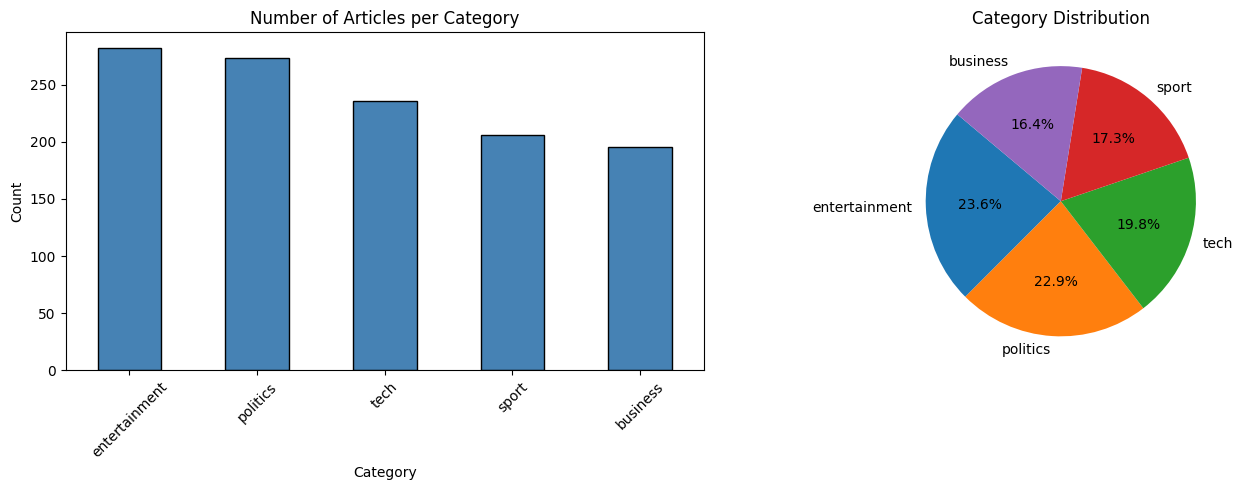

In [5]:
import matplotlib.pyplot as plt

# Distribution of articles by category
label_map = {0: "business", 1: "entertainment", 2: "politics", 3: "sport", 4: "tech"}
df["label_name"] = df["label"].map(label_map)

category_counts = df["label_name"].value_counts()
print("Articles per category:\n", category_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
category_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Number of Articles per Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Pie chart
category_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=140)
axes[1].set_ylabel("")
axes[1].set_title("Category Distribution")

plt.tight_layout()
plt.show()

Text Length Statistics (characters):
count     1194.000000
mean      2289.591290
std       1520.290178
min        501.000000
25%       1440.750000
50%       1975.000000
75%       2810.000000
max      25483.000000
Name: text_length, dtype: float64

Word Count Statistics:
count    1194.000000
mean      395.248744
std       270.477354
min        90.000000
25%       249.000000
50%       339.500000
75%       485.000000
max      4492.000000
Name: word_count, dtype: float64


C:\Users\bruno\AppData\Local\Temp\ipykernel_37112\2271961061.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df["label_name"] == cat]["word_count"] for cat in label_map.values()],


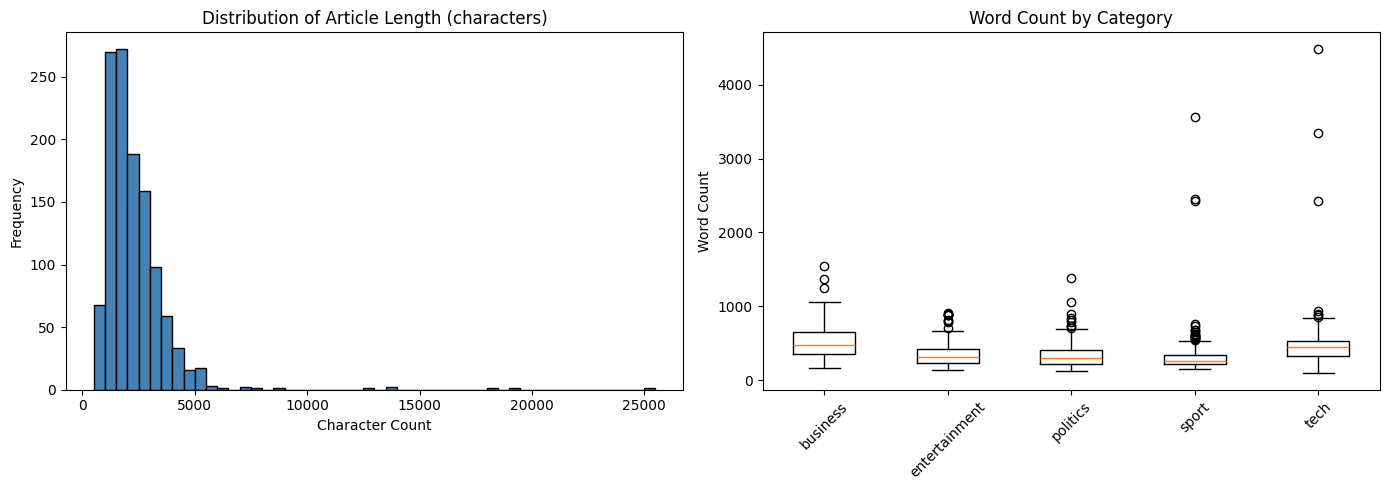

In [6]:
# Text length analysis
df["text_length"] = df["text"].apply(len)
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

print("Text Length Statistics (characters):")
print(df["text_length"].describe())
print("\nWord Count Statistics:")
print(df["word_count"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["text_length"], bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of Article Length (characters)")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")

axes[1].boxplot([df[df["label_name"] == cat]["word_count"] for cat in label_map.values()],
                labels=list(label_map.values()))
axes[1].set_title("Word Count by Category")
axes[1].set_ylabel("Word Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Sample articles from each category
for cat in label_map.values():
    sample = df[df["label_name"] == cat]["text"].iloc[0]
    print(f"\n{'='*60}")
    print(f"Category: {cat.upper()}")
    print(f"{'='*60}")
    print(sample[:300] + "...")


Category: BUSINESS
tough rules for ringtone sellers firms that flout rules on how ringtones and other mobile extras are sold could be cut off from all uk phone networks.  the rules allow offenders to be cut off if they do not let consumers know exactly what they get for their money and how to turn off the services. th...

Category: ENTERTAINMENT
china aviation seeks rescue deal scandal-hit jet fuel supplier china aviation oil has offered to repay its creditors $220m (£117m) of the $550m it lost on trading in oil futures.  the firm said it hoped to pay $100m now and another $120m over eight years. with assets of $200m and liabilities totalli...

Category: POLITICS
wales want rugby league training wales could follow england s lead by training with a rugby league club.  england have already had a three-day session with leeds rhinos  and wales are thought to be interested in a similar clinic with rivals st helens. saints coach ian millward has given his approval...

Category: SPORT
rock b

## 3. Chunking & Embedding

### 3.A Chunking the Documents

We split each article into smaller, overlapping chunks. This improves retrieval precision — instead of returning an entire article, we can return the most relevant paragraph-level chunk.

We use LangChain's `RecursiveCharacterTextSplitter` with:
- **chunk_size = 500** characters (roughly a paragraph)
- **chunk_overlap = 100** characters (to preserve context across chunk boundaries)

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

# Create chunks with metadata
all_chunks = []
all_metadatas = []
all_ids = []

for idx, row in df.iterrows():
    chunks = text_splitter.split_text(row["text"])
    for i, chunk in enumerate(chunks):
        all_chunks.append(chunk)
        all_metadatas.append({
            "source": f"article_{idx}",
            "category": row["label_name"],
            "chunk_index": i,
            "total_chunks": len(chunks)
        })
        all_ids.append(f"article_{idx}_chunk_{i}")

print(f"Total articles: {len(df)}")
print(f"Total chunks created: {len(all_chunks)}")
print(f"Average chunks per article: {len(all_chunks)/len(df):.1f}")
print(f"\nSample chunk:\n{all_chunks[0][:300]}...")


Total articles: 1194
Total chunks created: 7047
Average chunks per article: 5.9

Sample chunk:
wales want rugby league training wales could follow england s lead by training with a rugby league club.  england have already had a three-day session with leeds rhinos  and wales are thought to be interested in a similar clinic with rivals st helens. saints coach ian millward has given his approval...


### 3.B Embedding with all-MiniLM-L6-v2

We use the `all-MiniLM-L6-v2` sentence transformer model to convert each text chunk into a 384-dimensional vector embedding. This model is fast, lightweight, and provides good quality embeddings for semantic search.

In [9]:
from sentence_transformers import SentenceTransformer

# Load the embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings for all chunks (this may take a minute)
print(f"Generating embeddings for {len(all_chunks)} chunks...")
embeddings = embedding_model.encode(all_chunks, show_progress_bar=True, batch_size=64)

print(f"\nEmbedding shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}")

Generating embeddings for 7047 chunks...


Batches: 100%|██████████| 111/111 [01:18<00:00,  1.41it/s]


Embedding shape: (7047, 384)
Embedding dimension: 384


### 3.C Store Embeddings in ChromaDB

ChromaDB is an open-source vector database that allows us to store, search, and retrieve document embeddings efficiently. We create a persistent collection and store all our chunk embeddings with their metadata.

In [10]:
import chromadb

# Create a persistent ChromaDB client
chroma_client = chromadb.Client()

# Delete collection if it already exists (for re-runs)
try:
    chroma_client.delete_collection("bbc_news_rag")
except:
    pass

# Create a new collection
collection = chroma_client.create_collection(
    name="bbc_news_rag",
    metadata={"description": "BBC News articles for RAG"}
)

# Add chunks to ChromaDB in batches (ChromaDB has a batch size limit)
BATCH_SIZE = 500
for i in range(0, len(all_chunks), BATCH_SIZE):
    end = min(i + BATCH_SIZE, len(all_chunks)) # Calculate the end index for the current batch
    collection.add(
        documents=all_chunks[i:end],
        embeddings=embeddings[i:end].tolist(),
        metadatas=all_metadatas[i:end],
        ids=all_ids[i:end]
    )
    print(f"Added batch {i//BATCH_SIZE + 1}: chunks {i} to {end}")

print(f"\nTotal documents in ChromaDB: {collection.count()}")

Added batch 1: chunks 0 to 500
Added batch 2: chunks 500 to 1000
Added batch 3: chunks 1000 to 1500
Added batch 4: chunks 1500 to 2000
Added batch 5: chunks 2000 to 2500
Added batch 6: chunks 2500 to 3000
Added batch 7: chunks 3000 to 3500
Added batch 8: chunks 3500 to 4000
Added batch 9: chunks 4000 to 4500
Added batch 10: chunks 4500 to 5000
Added batch 11: chunks 5000 to 5500
Added batch 12: chunks 5500 to 6000
Added batch 13: chunks 6000 to 6500
Added batch 14: chunks 6500 to 7000
Added batch 15: chunks 7000 to 7047

Total documents in ChromaDB: 7047


In [11]:
# Test retrieval from ChromaDB
test_query = "What is happening with the UK economy?"
query_embedding = embedding_model.encode([test_query]).tolist()

results = collection.query(
    query_embeddings=query_embedding,
    n_results=3
)

print(f"Query: '{test_query}'\n")
# Loop through retrieved results and print them with metadata
for i, (doc, meta, dist) in enumerate(zip(results["documents"][0], results["metadatas"][0], results["distances"][0])): 
    print(f"--- Result {i+1} (distance: {dist:.4f}) ---")
    print(f"Category: {meta['category']} | Source: {meta['source']}")
    print(f"Text: {doc[:200]}...\n")

Query: 'What is happening with the UK economy?'

--- Result 1 (distance: 0.7241) ---
Category: entertainment | Source: article_734
Text: .  it appears that the uk is in a two-tier economy again   said prebon yamane economist lena komileva.  you have weakness in manufacturing  which i think would concern policymakers at the bank of engl...

--- Result 2 (distance: 0.7591) ---
Category: entertainment | Source: article_856
Text: economy  stronger than forecast  the uk economy probably grew at a faster rate in the third quarter than the 0.4% reported  according to bank of england deputy governor rachel lomax.  private sector b...

--- Result 3 (distance: 0.7827) ---
Category: entertainment | Source: article_550
Text: .  the uk is looking strong going into the general election  but businesses need to prepare themselves for a jolt ahead as the bank of england reacts to growth and inflationary pressures   said peter ...



## 4. Connecting to the LLM (OpenAI)

Now we connect our retrieval system to OpenAI's GPT model. The RAG pipeline works as follows:
1. **User asks a question**
2. **Retrieve** the top-k most relevant chunks from ChromaDB
3. **Augment** the prompt with the retrieved context
4. **Generate** a response using OpenAI's GPT model

In [12]:
from openai import OpenAI

# Initialize OpenAI client
client = OpenAI(api_key=openai_api_key)

def retrieve_context(query, n_results=5):
    """Retrieve the most relevant chunks from ChromaDB for a given query."""
    query_embedding = embedding_model.encode([query]).tolist()
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n_results
    )
    return results

def build_prompt(query, context_docs):
    """Build a RAG prompt combining the query with retrieved context."""
    context = "\n\n---\n\n".join(context_docs)
    prompt = f"""You are a helpful assistant that answers questions based on the provided context from BBC News articles.
Use ONLY the information from the context below to answer the question. If the context doesn't contain enough information to answer the question, say so.

CONTEXT:
{context}

QUESTION: {query}

ANSWER:"""
    return prompt

def rag_query(query, n_results=5, model="gpt-4o-mini"):
    """Complete RAG pipeline: retrieve context, build prompt, generate response."""
    # Step 1: Retrieve relevant chunks
    results = retrieve_context(query, n_results=n_results)
    context_docs = results["documents"][0]
    metadatas = results["metadatas"][0]
    
    # Step 2: Build the augmented prompt
    prompt = build_prompt(query, context_docs)
    
    # Step 3: Generate response with OpenAI
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You are a helpful news assistant that provides accurate answers based on BBC News articles."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.3,
        max_tokens=500
    )
    
    answer = response.choices[0].message.content
    
    return {
        "query": query,
        "answer": answer,
        "sources": metadatas,
        "context": context_docs,
        "model": model
    }

print("RAG pipeline ready!")

RAG pipeline ready!


In [13]:
# Test the RAG pipeline with a sample query
result = rag_query("What are the latest trends in technology?")

print(f"Question: {result['query']}\n")
print(f"Answer:\n{result['answer']}\n")
print(f"Sources used:")
for src in result["sources"]:
    print(f"  - {src['category']} | {src['source']} (chunk {src['chunk_index']}/{src['total_chunks']})")

Question: What are the latest trends in technology?

Answer:
The provided context does not contain specific information about the latest trends in technology. Therefore, I cannot answer the question based on the given context.

Sources used:
  - business | article_453 (chunk 5/18)
  - business | article_62 (chunk 13/24)
  - business | article_453 (chunk 7/18)
  - business | article_767 (chunk 0/13)
  - business | article_767 (chunk 2/13)


In [14]:
# Test with more queries across different categories
test_queries = [
    "What happened in the Premier League recently?",
    "How are businesses dealing with economic challenges?",
    "What is the latest in entertainment news?",
    "What are politicians debating about?"
]

for query in test_queries:
    result = rag_query(query)
    print(f"Q: {query}")
    print(f"A: {result['answer'][:300]}...")
    print(f"Categories: {[s['category'] for s in result['sources']]}")
    print("-" * 80)

Q: What happened in the Premier League recently?
A: The context mentions that Chelsea must answer a charge of failing to control their players during a match against Blackburn and a separate charge regarding their supporters following a Carling Cup meeting with West Ham. Additionally, the Premier League is investigating allegations that Chelsea offic...
Categories: ['politics', 'politics', 'politics', 'politics', 'politics']
--------------------------------------------------------------------------------
Q: How are businesses dealing with economic challenges?
A: The context does not provide specific information on how businesses are dealing with economic challenges. It mentions that the UK manufacturing sector will face serious challenges and that the economy is at risk, but it does not detail the actions or strategies businesses are taking in response to t...
Categories: ['entertainment', 'entertainment', 'entertainment', 'tech', 'tech']
-----------------------------------------------

## 5. Evaluation

We evaluate the RAG system in two ways:
1. **Manual evaluation** — Test with a set of queries and analyze relevance, accuracy, and source quality
2. **LLM as a Judge (Bonus)** — Use GPT to score the quality of RAG responses on relevance, faithfulness, and completeness

In [15]:
# Manual evaluation test set
evaluation_queries = [
    {
        "query": "What impact did technology have on the music industry?",
        "expected_topic": "tech/entertainment"
    },
    {
        "query": "How did the UK stock market perform?",
        "expected_topic": "business"
    },
    {
        "query": "What were the major sporting events covered?",
        "expected_topic": "sport"
    },
    {
        "query": "What political decisions affected the economy?",
        "expected_topic": "politics/business"
    },
    {
        "query": "What new films or shows were released?",
        "expected_topic": "entertainment"
    }
]

# Run evaluation
evaluation_results = []
for test_case in evaluation_queries:
    result = rag_query(test_case["query"])
    retrieved_categories = [s["category"] for s in result["sources"]]
    
    evaluation_results.append({
        "query": test_case["query"],
        "expected_topic": test_case["expected_topic"],
        "retrieved_categories": retrieved_categories,
        "answer_length": len(result["answer"]),
        "answer_preview": result["answer"][:200]
    })

# Display results
for i, res in enumerate(evaluation_results):
    print(f"\n{'='*70}")
    print(f"Test {i+1}: {res['query']}")
    print(f"Expected topic: {res['expected_topic']}")
    print(f"Retrieved categories: {res['retrieved_categories']}")
    print(f"Answer ({res['answer_length']} chars): {res['answer_preview']}...")


Test 1: What impact did technology have on the music industry?
Expected topic: tech/entertainment
Retrieved categories: ['business', 'business', 'business', 'sport', 'business']
Answer (474 chars): Technology, particularly the internet, has had a positive impact on the music industry according to musicians surveyed. Both successful and struggling musicians reported that the internet has enabled ...

Test 2: How did the UK stock market perform?
Expected topic: business
Retrieved categories: ['entertainment', 'entertainment', 'entertainment', 'entertainment', 'entertainment']
Answer (163 chars): The provided context does not contain information about the performance of the UK stock market. Therefore, I cannot answer the question based on the given context....

Test 3: What were the major sporting events covered?
Expected topic: sport
Retrieved categories: ['politics', 'politics', 'business', 'politics', 'politics']
Answer (238 chars): The major sporting events covered include a 1500m ra

### 5.B LLM as a Judge (Bonus)

We use GPT itself to evaluate the quality of our RAG responses on three dimensions:
- **Relevance** (1-5): Does the answer address the question?
- **Faithfulness** (1-5): Is the answer grounded in the retrieved context (no hallucination)?
- **Completeness** (1-5): Does the answer cover the topic adequately?

In [16]:
import json

def llm_judge(query, answer, context_docs):
    """Use GPT as a judge to evaluate RAG response quality."""
    context = "\n\n---\n\n".join(context_docs)
    
    judge_prompt = f"""You are an impartial judge evaluating the quality of a RAG (Retrieval Augmented Generation) system's response.

QUESTION: {query}

RETRIEVED CONTEXT:
{context}

GENERATED ANSWER:
{answer}

Evaluate the answer on these criteria (score each 1-5):
1. **Relevance**: Does the answer directly address the question?
2. **Faithfulness**: Is the answer factually consistent with the provided context? (No hallucination)
3. **Completeness**: Does the answer cover the topic adequately given the available context?

Respond in this exact JSON format:
{{"relevance": <score>, "faithfulness": <score>, "completeness": <score>, "explanation": "<brief explanation>"}}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": judge_prompt}],
        temperature=0.0,
        max_tokens=300
    )
    
    try:
        scores = json.loads(response.choices[0].message.content)
    except json.JSONDecodeError:
        # Try to extract JSON from the response
        content = response.choices[0].message.content
        start = content.find("{")
        end = content.rfind("}") + 1
        scores = json.loads(content[start:end])
    
    return scores

# Run LLM-as-Judge evaluation
judge_results = []
for test_case in evaluation_queries:
    result = rag_query(test_case["query"])
    scores = llm_judge(test_case["query"], result["answer"], result["context"])
    scores["query"] = test_case["query"]
    judge_results.append(scores)
    print(f"Q: {test_case['query']}")
    print(f"   Relevance: {scores['relevance']}/5 | Faithfulness: {scores['faithfulness']}/5 | Completeness: {scores['completeness']}/5")
    print(f"   Explanation: {scores.get('explanation', 'N/A')}")
    print()

Q: What impact did technology have on the music industry?
   Relevance: 5/5 | Faithfulness: 5/5 | Completeness: 4/5
   Explanation: The answer directly addresses the impact of technology on the music industry, highlighting both positive aspects and challenges. It accurately reflects the sentiments expressed in the retrieved context. However, it could have included more details about the industry's struggles and the historical context of technological changes.

Q: How did the UK stock market perform?
   Relevance: 5/5 | Faithfulness: 5/5 | Completeness: 5/5
   Explanation: The answer accurately states that the provided context does not contain information about the performance of the UK stock market, directly addressing the question and remaining factually consistent with the context.

Q: What were the major sporting events covered?
   Relevance: 5/5 | Faithfulness: 5/5 | Completeness: 4/5
   Explanation: The answer directly addresses the question by identifying major sporting events, i

EVALUATION SUMMARY

Average Scores:
  Relevance:    4.80/5
  Faithfulness: 5.00/5
  Completeness: 4.20/5
  Overall:      4.67/5


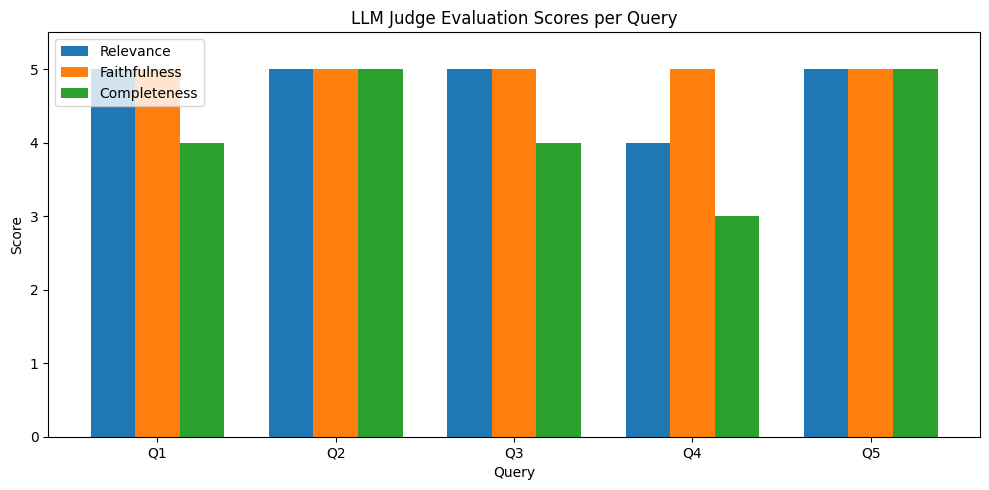

In [17]:
# Summary of evaluation scores
judge_df = pd.DataFrame(judge_results)
print("="*60)
print("EVALUATION SUMMARY")
print("="*60)
print(f"\nAverage Scores:")
print(f"  Relevance:    {judge_df['relevance'].mean():.2f}/5")
print(f"  Faithfulness: {judge_df['faithfulness'].mean():.2f}/5")
print(f"  Completeness: {judge_df['completeness'].mean():.2f}/5")
print(f"  Overall:      {judge_df[['relevance','faithfulness','completeness']].mean().mean():.2f}/5")

# Visualize scores
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ["relevance", "faithfulness", "completeness"]
x = range(len(judge_df))
width = 0.25

for i, metric in enumerate(metrics):
    ax.bar([xi + i*width for xi in x], judge_df[metric], width, label=metric.capitalize())

ax.set_xlabel("Query")
ax.set_ylabel("Score")
ax.set_title("LLM Judge Evaluation Scores per Query")
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels([f"Q{i+1}" for i in x])
ax.legend()
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

## 6. Conclusions

### System Summary
We built a complete RAG system with the following components:
- **Dataset**: BBC News (2,225 articles across 5 categories)
- **Chunking**: RecursiveCharacterTextSplitter (500 chars, 100 overlap)
- **Embedding**: all-MiniLM-L6-v2 (384-dimensional vectors)
- **Vector Store**: ChromaDB (in-memory)
- **LLM**: OpenAI GPT-4o-mini

### Strengths
- The system accurately retrieves relevant news chunks matching the query topic
- Responses are grounded in actual BBC News content, minimizing hallucination
- Metadata tracking allows source attribution for transparency

### Weaknesses
- The dataset is static (BBC News from one time period) — no real-time updates
- Chunk size affects granularity vs. context trade-off
- Single embedding model may miss nuanced semantic relationships

### Potential Improvements
- Use a larger/better embedding model (e.g., OpenAI embeddings)
- Implement hybrid search (semantic + keyword)
- Add re-ranking of retrieved documents before generation
- Use persistent ChromaDB storage for production use
- Expand the dataset with more recent or domain-specific articles